In [16]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split 
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cpu


In [17]:
dataset_path = r"C:\Users\Lenovo\PycharmProjects\PythonProject\archive (1)"

In [18]:
import os
path = r"C:\Users\Lenovo\PycharmProjects\PythonProject\archive (1)"
for folder in os.listdir(path):
    full = os.path.join(path, folder)
    if os.path.isdir(full):
        files = os.listdir(full)
        print(folder, len(files), "files, e.g.", files[:2])

Testing 4 files, e.g. ['glioma', 'meningioma']
Training 4 files, e.g. ['glioma', 'meningioma']


In [19]:
transform_train = transforms.Compose([

    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
     transforms.RandomResizedCrop(
        128,
        scale=(0.8, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

transform_val = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

transform = transform_train


In [20]:
print(dataset_path)
import os
if os.path.exists(dataset_path):
    print("Subfolders:", os.listdir(dataset_path))
else:
    print("Path does not exist!")

C:\Users\Lenovo\PycharmProjects\PythonProject\archive (1)
Subfolders: ['Testing', 'Training']


In [21]:
train_path = os.path.join(dataset_path, "Training")
test_path  = os.path.join(dataset_path, "Testing")

dataset_train = datasets.ImageFolder(root=train_path, transform=transform_train)
dataset_test  = datasets.ImageFolder(root=test_path,  transform=transform_val)

val_size      = int(0.2 * len(dataset_train))
train_size    = len(dataset_train) - val_size
train_dataset, val_dataset = random_split(dataset_train, [train_size, val_size])

class_names = dataset_train.classes

print("Classes:", class_names)
print("Number of Classes:", len(class_names))
print("\nDataset Split:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(dataset_test))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of Classes: 4

Dataset Split:
Train: 4480
Validation: 1120
Test: 1600


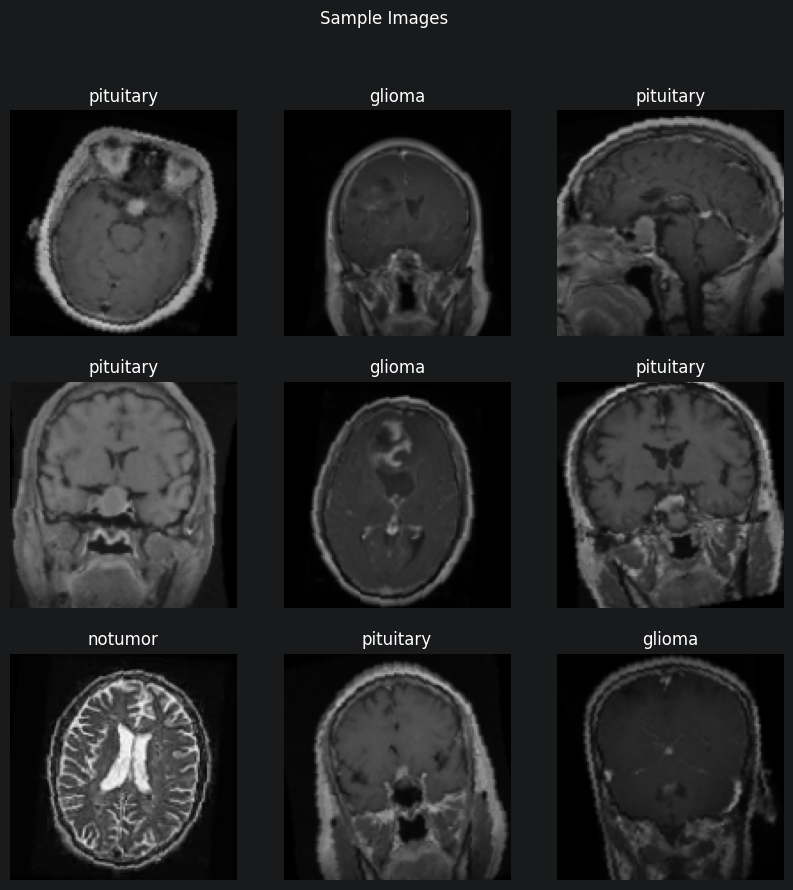

In [22]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset_test,
    batch_size=batch_size,
    shuffle=False
)

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 10))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    image = images[i].permute(1, 2, 0).numpy()

    image = (image * 0.5) + 0.5

    plt.imshow(image)

    plt.title(class_names[labels[i]])

    plt.axis("off")

plt.suptitle("Sample Images")
plt.show()


In [23]:
import os

print("dataset_path:", dataset_path)
print("\nContents of dataset_path:")
for item in os.listdir(dataset_path):
    full = os.path.join(dataset_path, item)
    kind = "DIR" if os.path.isdir(full) else "FILE"
    print(f"  [{kind}] {item}")

    if os.path.isdir(full):
        sub = os.listdir(full)
        print(f" {len(sub)} items, e.g.: {sub[:3]}")

dataset_path: C:\Users\Lenovo\PycharmProjects\PythonProject\archive (1)

Contents of dataset_path:
  [DIR] Testing
         → 4 items, e.g.: ['glioma', 'meningioma', 'notumor']
  [DIR] Training
         → 4 items, e.g.: ['glioma', 'meningioma', 'notumor']


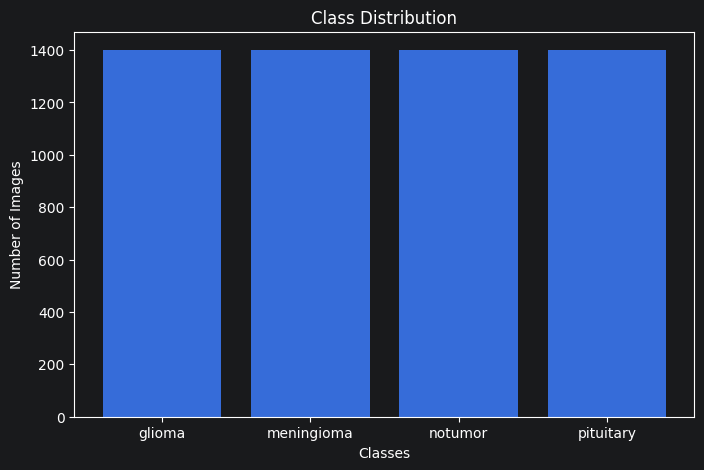

In [24]:
class_counts = []

for class_name in class_names:
    class_path = os.path.join(train_path, class_name)
    class_counts.append(len(os.listdir(class_path)))

plt.figure(figsize=(8,5))
plt.bar(class_names, class_counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [25]:
class FFNN(nn.Module):

    def __init__(self, num_classes):

        super(FFNN, self).__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(128 * 128 * 3, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):

        x = self.flatten(x)

        x = self.network(x)

        return x


In [26]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256 * 8 * 8, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


In [27]:
def train_model(model, train_loader, val_loader, epochs=10 ):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    patience_counter = 0
    early_stop_patience = 10
    best_model_state = None

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        running_train_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        train_loss = running_train_loss / len(train_loader)

        train_losses.append(train_loss)

        model.eval()

        running_val_loss = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

        val_loss = running_val_loss / len(val_loader)

        val_losses.append(val_loss)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                model.load_state_dict(best_model_state)
                break

        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Validation Loss: {val_loss:.4f}")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    total_training_time = time.time() - start_time

    return train_losses, val_losses, total_training_time


In [28]:
def evaluate_model(model, test_loader):

    model.eval()

    predictions = []
    true_labels = []

    start_time = time.time()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            predictions.extend(predicted.cpu().numpy())

            true_labels.extend(labels.numpy())

    inference_time = time.time() - start_time

    accuracy = accuracy_score(
        true_labels,
        predictions
    )

    print("\nAccuracy:", accuracy)

    print("\nClassification Report:\n")

    print(classification_report(
        true_labels,
        predictions,
        target_names=class_names
    ))

    print("\nConfusion Matrix:\n")

    print(confusion_matrix(
        true_labels,
        predictions
    ))

    return accuracy, inference_time


In [29]:
ffnn_model = FFNN(
    num_classes=len(class_names)
).to(device)


print("FFNN training: ")

ffnn_train_losses, ffnn_val_losses, ffnn_train_time = train_model(
    ffnn_model,
    train_loader,
    val_loader,
    epochs=30
)


FFNN training: 

Epoch [1/30]
Train Loss: 0.9074
Validation Loss: 0.8424

Epoch [2/30]
Train Loss: 0.7961
Validation Loss: 0.8174

Epoch [3/30]
Train Loss: 0.7360
Validation Loss: 0.7783

Epoch [4/30]
Train Loss: 0.7130
Validation Loss: 0.7674

Epoch [5/30]
Train Loss: 0.6991
Validation Loss: 0.7392

Epoch [6/30]
Train Loss: 0.6888
Validation Loss: 0.6504

Epoch [7/30]
Train Loss: 0.6840
Validation Loss: 0.9303

Epoch [8/30]
Train Loss: 0.6870
Validation Loss: 0.8920

Epoch [9/30]
Train Loss: 0.6637
Validation Loss: 0.7024

Epoch [10/30]
Train Loss: 0.6625
Validation Loss: 0.8389

Epoch [11/30]
Train Loss: 0.6471
Validation Loss: 0.9557

Epoch [12/30]
Train Loss: 0.6466
Validation Loss: 0.7746

Epoch [13/30]
Train Loss: 0.6141
Validation Loss: 0.6043

Epoch [14/30]
Train Loss: 0.6034
Validation Loss: 0.7650

Epoch [15/30]
Train Loss: 0.5902
Validation Loss: 0.5907

Epoch [16/30]
Train Loss: 0.5784
Validation Loss: 0.7673

Epoch [17/30]
Train Loss: 0.5915
Validation Loss: 0.7653

Epoch 

In [30]:
print("CNN training: ")
cnn_model = CNN(
    num_classes=len(class_names)
).to(device)

cnn_train_losses, cnn_val_losses, cnn_train_time = train_model(
    cnn_model,
    train_loader,
    val_loader,
    epochs=30,
)


CNN training: 

Epoch [1/30]
Train Loss: 0.6360
Validation Loss: 0.7731

Epoch [2/30]
Train Loss: 0.4459
Validation Loss: 0.4079

Epoch [3/30]
Train Loss: 0.3726
Validation Loss: 0.3548

Epoch [4/30]
Train Loss: 0.3093
Validation Loss: 0.3540

Epoch [5/30]
Train Loss: 0.2922
Validation Loss: 0.2663

Epoch [6/30]
Train Loss: 0.2501
Validation Loss: 0.2777

Epoch [7/30]
Train Loss: 0.2391
Validation Loss: 0.2631

Epoch [8/30]
Train Loss: 0.2221
Validation Loss: 0.4343

Epoch [9/30]
Train Loss: 0.2026
Validation Loss: 0.2805

Epoch [10/30]
Train Loss: 0.1926
Validation Loss: 0.2374

Epoch [11/30]
Train Loss: 0.1630
Validation Loss: 0.4054

Epoch [12/30]
Train Loss: 0.1855
Validation Loss: 0.1832

Epoch [13/30]
Train Loss: 0.1688
Validation Loss: 0.1791

Epoch [14/30]
Train Loss: 0.1646
Validation Loss: 0.1497

Epoch [15/30]
Train Loss: 0.1708
Validation Loss: 0.3252

Epoch [16/30]
Train Loss: 0.1323
Validation Loss: 0.2367

Epoch [17/30]
Train Loss: 0.1393
Validation Loss: 0.2567

Epoch [

In [31]:
print("evaluating FFNN")

ffnn_accuracy, ffnn_inference_time = evaluate_model(
    ffnn_model,
    test_loader
)


evaluating FFNN

Accuracy: 0.725625

Classification Report:

              precision    recall  f1-score   support

      glioma       0.65      0.69      0.67       400
  meningioma       0.64      0.50      0.56       400
     notumor       0.73      0.88      0.79       400
   pituitary       0.87      0.84      0.86       400

    accuracy                           0.73      1600
   macro avg       0.72      0.73      0.72      1600
weighted avg       0.72      0.73      0.72      1600


Confusion Matrix:

[[275  57  46  22]
 [ 93 199  84  24]
 [ 31  16 350   3]
 [ 24  37   2 337]]


In [32]:
print("evaluating CNN: ")

cnn_accuracy, cnn_inference_time = evaluate_model(
    cnn_model,
    test_loader
)


evaluating CNN: 

Accuracy: 0.931875

Classification Report:

              precision    recall  f1-score   support

      glioma       0.98      0.79      0.87       400
  meningioma       0.91      0.95      0.93       400
     notumor       0.88      1.00      0.94       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600


Confusion Matrix:

[[315  35  44   6]
 [  5 380  10   5]
 [  0   0 400   0]
 [  3   1   0 396]]


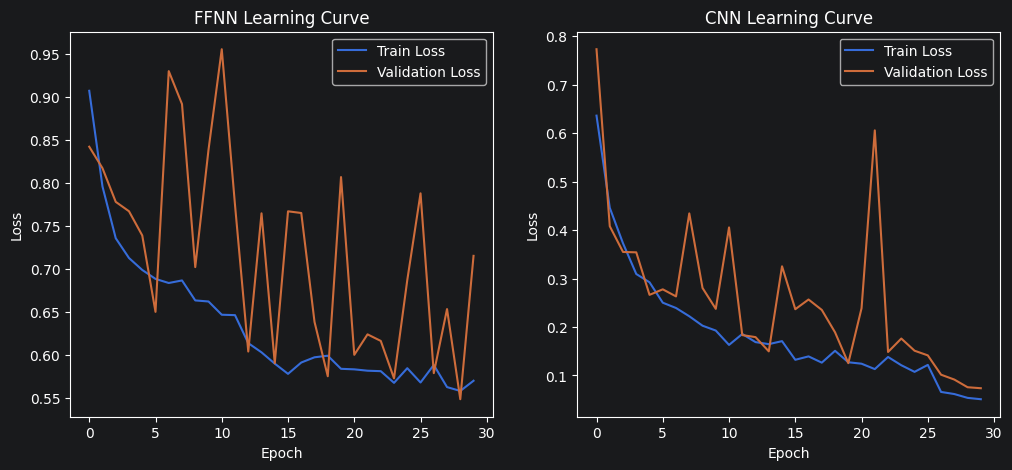

In [33]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

plt.plot(ffnn_train_losses, label="Train Loss")
plt.plot(ffnn_val_losses, label="Validation Loss")

plt.title("FFNN Learning Curve")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.subplot(1,2,2)
plt.plot(cnn_train_losses, label="Train Loss")
plt.plot(cnn_val_losses, label="Validation Loss")
plt.title("CNN Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

final comparison: 
FFNN Accuracy: 0.7256
CNN Accuracy : 0.9319

FFNN Training Time: 1273.77 seconds
CNN Training Time : 1621.96 seconds

FFNN Inference Time: 5.4022 seconds
CNN Inference Time : 7.3202 seconds


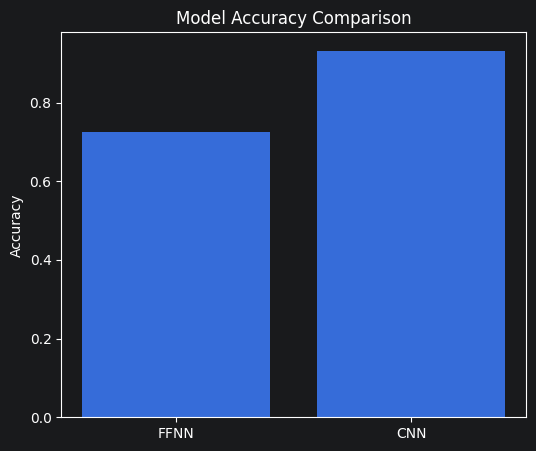

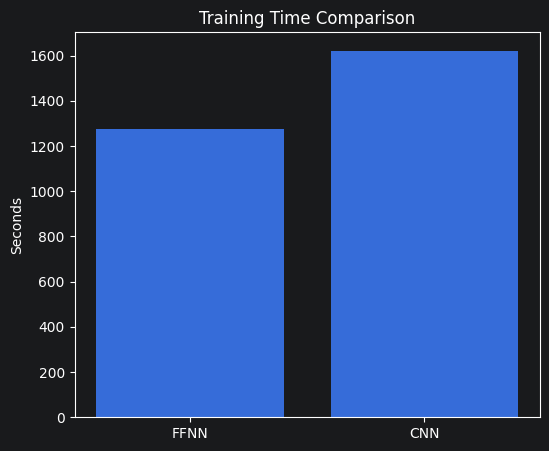

In [34]:
print("final comparison: ")
print("FFNN Accuracy:", round(ffnn_accuracy, 4))
print("CNN Accuracy :", round(cnn_accuracy, 4))

print("\nFFNN Training Time:", round(ffnn_train_time, 2), "seconds")
print("CNN Training Time :", round(cnn_train_time, 2), "seconds")

print("\nFFNN Inference Time:", round(ffnn_inference_time, 4), "seconds")
print("CNN Inference Time :", round(cnn_inference_time, 4), "seconds")


models = ["FFNN", "CNN"]

accuracies = [
    ffnn_accuracy,
    cnn_accuracy
]

training_times = [
    ffnn_train_time,
    cnn_train_time
]

plt.figure(figsize=(6,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()


plt.figure(figsize=(6,5))

plt.bar(models, training_times)

plt.title("Training Time Comparison")
plt.ylabel("Seconds")

plt.show()


In [35]:
torch.save(ffnn_model.state_dict(), r"C:\Users\Lenovo\PycharmProjects\PythonProject\ffnn_model.pth")
torch.save(cnn_model.state_dict(), r"C:\Users\Lenovo\PycharmProjects\PythonProject\cnn_model.pth")